# Assignment 1 2AMM10 2025-2026

## Group: [Fill in your group name]
### Member 1: [Wessel Bekx]
### Member 2: Quincy Salden
### Member 3: [Fill in your name]

## Task 1 

Dataset and visualization

In [1]:
import os
import re
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import kagglehub
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

class AppleDataset(Dataset):
    def __init__(self, transform=None, subset="train",class_subset = "main"):
        assert subset in ["train","test"]
        assert class_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        all_folders = sorted(os.listdir(self.path))
        self.item_folders = sorted(x for x in all_folders if x.lower().startswith("apple"))
        generator=np.random.default_rng(6)
        generator.shuffle(self.item_folders)
        if class_subset == "main":
            self.item_folders = self.item_folders[:20]
        elif class_subset == "new":
            self.item_folders = self.item_folders[20:]
        self.targets = []
        self.image_paths = []
        for i, folder in enumerate(self.item_folders):
            for img_file in sorted(os.listdir(self.path / folder)):
                if img_file.startswith("r0"):
                    if class_subset=="new":
                        self.targets.append(i+20)
                    else: 
                        self.targets.append(i)
                    self.image_paths.append(self.path / folder / img_file)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, i):
        image = Image.open(self.image_paths[i]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.targets[i]

dataset = AppleDataset()

item_dd = widgets.Dropdown(options=dataset.item_folders, description="Variety:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(folder):
    return sorted(f for f in os.listdir(dataset.path / folder)
                  if f.startswith("r0_") and f.endswith(".jpg"))

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([item_dd, frame_slider, output]))

100%|██████████| 5.99G/5.99G [05:47<00:00, 18.5MB/s]

Extracting files...


In [6]:
import torch.nn as nn 
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn.functional as F

transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.RandomRotation(degrees=15, fill=(255, 255, 255)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
train_data = AppleDataset(subset="train",transform=transform)
test_data = AppleDataset(subset="test",transform=transform)
support_new_data = AppleDataset(subset="train",transform=transform,class_subset="new")
test_new_data = AppleDataset(subset="test",transform=transform,class_subset="new")

# your code here
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


In [7]:
#prompts used: 1. Can you write a class which creates a CNN with 4 layers using ReLU and maxpooling followed by a flatten layer and 2 linear layers.
#              2. For the loss function I want to use Triplet Margin Loss. For this I need a miner function to extract the triplets. Can you code a framework for this miner function and the subsequent training loop
#              3. Can you code 2 helper functions: 1 to extract all the embeddings from the dataset and 1 to calculate the average of the training embeddings for all different types of apple
class AppleEmbedder(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Linear(2304, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        embeddings = self.fc(x)
        return F.normalize(embeddings, p=2, dim=1)

def mine_triplets_online(embeddings, labels):
   
    device = embeddings.device
    dist_matrix = torch.cdist(embeddings, embeddings)  # (N, N)
    
    labels_equal = labels.unsqueeze(0) == labels.unsqueeze(1)
    identity_mask = torch.eye(len(labels), dtype=torch.bool, device=device)
    
    pos_mask = labels_equal & ~identity_mask
    neg_mask = ~labels_equal
    
    # Hard positive: furthest positive
    pos_dist = dist_matrix.clone()
    pos_dist[~pos_mask] = -1e9
    hard_pos_idx = pos_dist.argmax(dim=1)
    
    # Hard negative: closest negative
    neg_dist = dist_matrix.clone()
    neg_dist[~neg_mask] = 1e9
    hard_neg_idx = neg_dist.argmin(dim=1)
    
    valid = pos_mask.any(dim=1) & neg_mask.any(dim=1)
    idx = valid.nonzero(as_tuple=True)[0]

    if len(idx) == 0:
        return None, None, None
    
    return embeddings[idx], embeddings[hard_pos_idx[idx]], embeddings[hard_neg_idx[idx]]

# Training Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AppleEmbedder(embedding_dim=128).to(device)

criterion = nn.TripletMarginLoss(margin=0.5, p=2) 
optimizer = optim.Adam(model.parameters(), lr=0.001)

#The Training Loop for the NN
epochs = 10
print(f"Training on {device}...")

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    valid_batches = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        embeddings = model(images)
        
        anchors, positives, negatives = mine_triplets_online(embeddings, labels)
        
        if anchors is None:
            continue
            
        loss = criterion(anchors, positives, negatives)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        valid_batches += 1
        
    avg_loss = total_loss / valid_batches if valid_batches > 0 else 0
    print(f"Epoch {epoch+1}/{epochs} | Average Triplet Loss: {avg_loss:.4f}")

# Helper function to extract embeddings for a whole dataset
@torch.no_grad() 
def extract_embeddings(dataloader, model, device):
    model.eval() 
    all_embeddings = []
    all_labels = []
    
    for images, labels in dataloader:
        images = images.to(device)
        embeddings = model(images)
        all_embeddings.append(embeddings.cpu())
        all_labels.append(labels.cpu())
        
    return torch.cat(all_embeddings), torch.cat(all_labels)

print("Extracting embeddings...")
# Extract representations for the training (support) set and the test set
train_embeds, train_labels = extract_embeddings(train_loader, model, device)
test_embeds, test_labels = extract_embeddings(test_loader, model, device)

# Calculate the center for each apple variety
def calculate_prototypes(embeddings, labels):
    unique_labels = torch.unique(labels)
    prototypes = []
    
    for label in unique_labels:
        # Filter embeddings belonging to this specific class
        class_embeds = embeddings[labels == label]
        
        # Calculate the mean across the batch dimension (dim=0)
        class_proto = class_embeds.mean(dim=0)
        
        # Re-normalize the prototype so it stays on our hypersphere
        class_proto = torch.nn.functional.normalize(class_proto, p=2, dim=0)
        prototypes.append(class_proto)
        
    return torch.stack(prototypes), unique_labels

prototypes, proto_labels = calculate_prototypes(train_embeds, train_labels)

# Predict and evaluate accuracy
def evaluate_accuracy(test_embeds, test_labels, prototypes, proto_labels):
    # torch.cdist calculates the Euclidean distance between every test image and every prototype. 
    distances = torch.cdist(test_embeds, prototypes)
    
    # Find the index of the minimum distance for each test image
    min_dist_indices = torch.argmin(distances, dim=1)
    
    # Map the index back to the actual class label
    predictions = proto_labels[min_dist_indices]
    
    # Calculate accuracy
    correct = (predictions == test_labels).sum().item()
    accuracy = correct / len(test_labels)
    return accuracy

accuracy = evaluate_accuracy(test_embeds, test_labels, prototypes, proto_labels)
print(f"Test Accuracy on Seen Items: {accuracy * 100:.2f}%")
support_new_loader = DataLoader(support_new_data, batch_size=batch_size, shuffle=False)
test_new_loader = DataLoader(test_new_data, batch_size=batch_size, shuffle=False)

# Extract embeddings for the new support and test sets
print("Extracting embeddings for unseen apples...")
support_new_embeds, support_new_labels = extract_embeddings(support_new_loader, model, device)
test_new_embeds, test_new_labels = extract_embeddings(test_new_loader, model, device)

# Calculate prototypes for the 10 new apple varieties
new_prototypes, new_proto_labels = calculate_prototypes(support_new_embeds, support_new_labels)

# Predict and evaluate using the new prototypes
new_accuracy = evaluate_accuracy(test_new_embeds, test_new_labels, new_prototypes, new_proto_labels)
print(f"Test Accuracy on Unseen Items: {new_accuracy * 100:.2f}%")

Training on cpu...


c:\Users\20213053\AppData\Local\anaconda3\envs\clean-dl\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Average Triplet Loss: 0.1441
Epoch 2/10 | Average Triplet Loss: 0.0111
Epoch 3/10 | Average Triplet Loss: 0.0013
Epoch 4/10 | Average Triplet Loss: 0.0030
Epoch 5/10 | Average Triplet Loss: 0.0019
Epoch 6/10 | Average Triplet Loss: 0.0081
Epoch 7/10 | Average Triplet Loss: 0.0010
Epoch 8/10 | Average Triplet Loss: 0.0008
Epoch 9/10 | Average Triplet Loss: 0.0002
Epoch 10/10 | Average Triplet Loss: 0.0001
Extracting embeddings...


KeyboardInterrupt: 

## Task 2

In [4]:
class GardenDataset(Dataset):
    def __init__(self, transform=None, class_level="item", subset="train", family_subset="main", item_subset="main"):
        assert class_level in ["item","family","both"]
        assert subset in ["train","test"]
        assert family_subset in ["main","new","all"]
        assert item_subset in ["main","new","all"]
        path = kagglehub.dataset_download("moltean/fruits")
        base = Path(path) / "fruits-360_original-size" / "fruits-360-original-size"
        if subset == "train":
            self.path = base / "Training"
        elif subset == "test":
            self.path = base / "Validation"
        self.transform = transform
        self.class_level = class_level

        canonical_items = sorted(
            d for d in os.listdir(base / "Training")
            if (base / "Training" / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        )
        item_to_family = {it: it.rsplit(' ', 1)[0] for it in canonical_items}
        canonical_families = sorted(set(item_to_family.values()))

        self.item_to_idx = {c: i for i, c in enumerate(canonical_items)}
        self.family_to_idx = {c: i for i, c in enumerate(canonical_families)}

        train_fam_to_items = defaultdict(list)
        for it in canonical_items:
            train_fam_to_items[item_to_family[it]].append(it)
        for fam in train_fam_to_items:
            train_fam_to_items[fam].sort(key=lambda x: int(x.rsplit(' ', 1)[1]))

        new_families = {fam for fam, its in train_fam_to_items.items() if len(its) == 1}
        new_items = set()
        for fam, its in train_fam_to_items.items():
            if len(its) >= 3:
                new_items.add(its[0]) 

        present = {
            d for d in os.listdir(self.path)
            if (self.path / d).is_dir() and re.fullmatch(r'\S+ \d+', d)
        }
        all_items = [it for it in canonical_items if it in present]

        if family_subset == "main":
            all_items = [it for it in all_items if item_to_family[it] not in new_families]
        elif family_subset == "new":
            all_items = [it for it in all_items if item_to_family[it] in new_families]

        if item_subset == "main":
            all_items = [it for it in all_items if it not in new_items]
        elif item_subset == "new":
            all_items = [it for it in all_items if it in new_items]

        self.items = all_items
        self.item_to_family = {it: item_to_family[it] for it in self.items}
        self.families = sorted(set(self.item_to_family.values()))
        self.new_families = new_families
        self.new_items = new_items

        # Build samples using canonical (global) indices
        self.image_paths = []
        self.targets_item = []
        self.targets_family = []
        for item in self.items:
            item_dir = self.path / item
            item_label = self.item_to_idx[item]
            family_label = self.family_to_idx[item_to_family[item]]
            for img_file in sorted(os.listdir(item_dir)):
                if img_file.endswith('.jpg'):
                    self.image_paths.append(item_dir / img_file)
                    self.targets_item.append(item_label)
                    self.targets_family.append(family_label)

        if class_level == "item":
            self.classes = self.items
            self.class_to_idx = self.item_to_idx
            self.targets = self.targets_item
        elif class_level == "family":
            self.classes = self.families
            self.class_to_idx = self.family_to_idx
            self.targets = self.targets_family

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.class_level == "both":
             return image, self.targets_family[idx], self.targets_item[idx]
        return image, self.targets[idx]

    def get_items_for_family(self, family):
        return sorted(item for item, fam in self.item_to_family.items() if fam == family)

dataset = GardenDataset()

family_dd = widgets.Dropdown(options=dataset.families, description="Family:")
item_dd = widgets.Dropdown(options=dataset.get_items_for_family(dataset.families[0]), description="Item:")
frame_slider = widgets.IntSlider(value=0, min=0, max=0, description="Frame:")
output = widgets.Output()


def get_frames(item):
    return sorted(f for f in os.listdir(dataset.path / item) if f.endswith(".jpg"))

def update_items(*_):
    items = dataset.get_items_for_family(family_dd.value)
    item_dd.options = items
    item_dd.value = items[0]

def update_slider(*_):
    frames = get_frames(item_dd.value)
    frame_slider.max = max(0, len(frames) - 1)
    frame_slider.value = min(frame_slider.value, frame_slider.max)
    show_image()

def show_image(*_):
    frames = get_frames(item_dd.value)
    if not frames or frame_slider.value >= len(frames):
        return
    with output:
        clear_output(wait=True)
        img = Image.open(dataset.path / item_dd.value / frames[frame_slider.value])
        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img)
        ax.set_title(f"{family_dd.value} | {item_dd.value} | frame {frame_slider.value}")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

family_dd.observe(update_items, names="value")
item_dd.observe(update_slider, names="value")
frame_slider.observe(show_image, names="value")

update_slider()
display(widgets.VBox([family_dd, item_dd, frame_slider, output]))

In [10]:
train_data = GardenDataset(subset="train", transform=transform)

# scenario 1 
test_data = GardenDataset(subset="test", transform=transform)

# scenario 2 
train_data_family = GardenDataset(subset="train", transform=transform, class_level="family")
test_data_family = GardenDataset(subset="test", transform=transform, class_level="family")

# scenario 3 
support_all_data = GardenDataset(subset="train", transform=transform, item_subset="all")
test_new_data = GardenDataset(subset="test", transform=transform, item_subset="new")

# scenario 4 
support_all_data_family = GardenDataset(subset="train", transform=transform, family_subset="all",class_level="family")
test_new_data_family = GardenDataset(subset="test", transform=transform, family_subset="new",class_level="family")

# your code here
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
#scenario 1 loaders
support_loader_s1 = DataLoader(train_data, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader_s1 = DataLoader(test_data, batch_size=batch_size, shuffle=False)
#scenario 2 loaders
support_loader_s2 = DataLoader(train_data_family, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader_s2 = DataLoader(test_data_family, batch_size=batch_size, shuffle=False)
#scenario 3 loaders
support_loader_s3 = DataLoader(support_all_data, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader_s3 = DataLoader(test_new_data, batch_size=batch_size, shuffle=False)
#scenario 4 loaders
support_loader_s4 = DataLoader(support_all_data_family, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader_s4 = DataLoader(test_new_data_family, batch_size=batch_size, shuffle=False)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
task2_model = AppleEmbedder(embedding_dim=512).to(device) 
criterion = nn.TripletMarginLoss(margin=0.5, p=2)
optimizer = optim.Adam(task2_model.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 15
print(f"Training on {device}")
for epoch in range(epochs):
    task2_model.train()
    total_loss = 0.0
    valid_batches = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass to extract embeddings
        embeddings = task2_model(images)
        
        # Mine triplets 
        anchors, positives, negatives = mine_triplets_online(embeddings, labels)
        
        if anchors is None:
            continue
            
        # Calculate loss and backpropagate
        loss = criterion(anchors, positives, negatives)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        valid_batches += 1
        
            
    avg_loss = total_loss / valid_batches if valid_batches > 0 else 0
    print(f"==> Epoch {epoch+1}/{epochs} Completed | Average Triplet Loss: {avg_loss:.4f}\n")






Training on cuda
==> Epoch 1/15 Completed | Average Triplet Loss: 0.2933

==> Epoch 2/15 Completed | Average Triplet Loss: 0.1130

==> Epoch 3/15 Completed | Average Triplet Loss: 0.0569

==> Epoch 4/15 Completed | Average Triplet Loss: 0.0320

==> Epoch 5/15 Completed | Average Triplet Loss: 0.0265

==> Epoch 6/15 Completed | Average Triplet Loss: 0.0176

==> Epoch 7/15 Completed | Average Triplet Loss: 0.0160

==> Epoch 8/15 Completed | Average Triplet Loss: 0.0174

==> Epoch 9/15 Completed | Average Triplet Loss: 0.0160

==> Epoch 10/15 Completed | Average Triplet Loss: 0.0135

==> Epoch 11/15 Completed | Average Triplet Loss: 0.0133

==> Epoch 12/15 Completed | Average Triplet Loss: 0.0153

==> Epoch 13/15 Completed | Average Triplet Loss: 0.0136

==> Epoch 14/15 Completed | Average Triplet Loss: 0.0125

==> Epoch 15/15 Completed | Average Triplet Loss: 0.0099



Scenario 1 (Main Items) Accuracy: 99.84%
Scenario 2 (Main Families) Accuracy: 99.93%
Scenario 3 (New Items) Accuracy: 99.85%
Scenario 4 (New Families) Accuracy: 95.33%


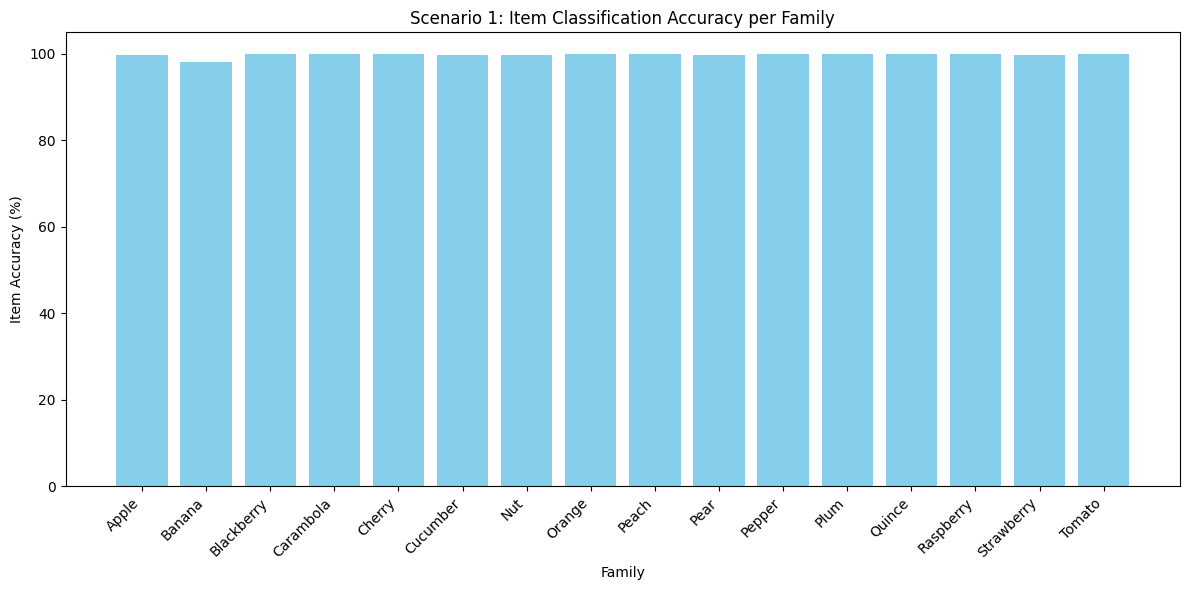

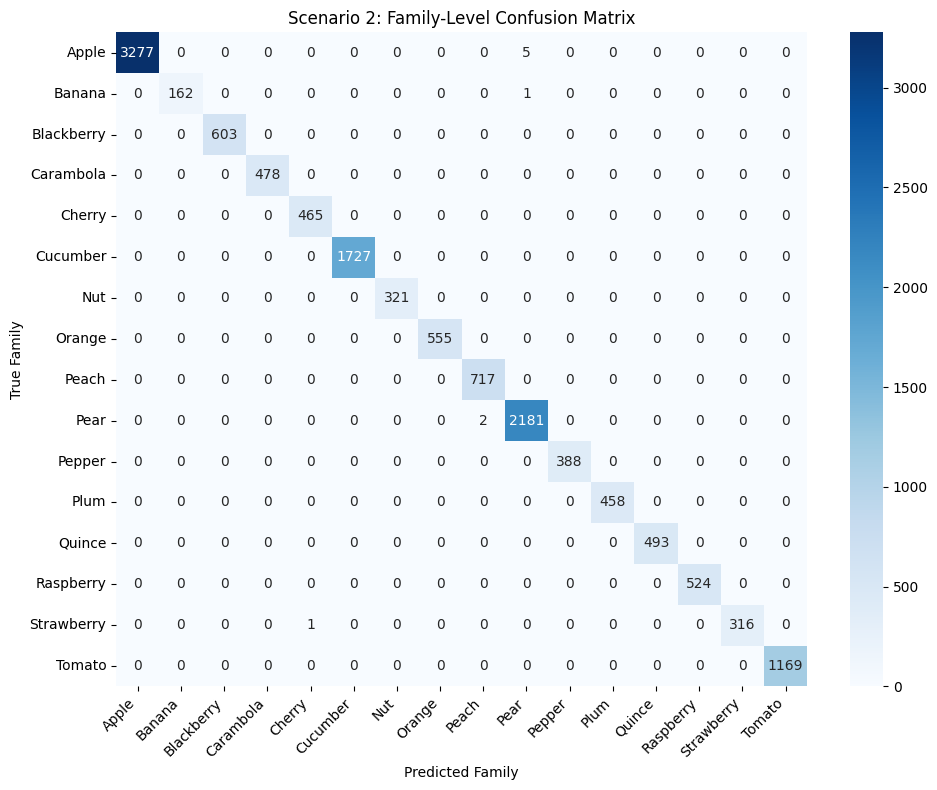

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

def get_predictions_task2(test_embeds, prototypes, proto_labels):
    # Calculate Euclidean distance between test images and prototypes
    distances = torch.cdist(test_embeds, prototypes)
    min_dist_indices = torch.argmin(distances, dim=1)
    return proto_labels[min_dist_indices]

def get_predictions_family_via_items(test_embeds, item_prototypes, item_proto_labels, item_to_family_map):
    # Find nearest item prototype
    distances = torch.cdist(test_embeds, item_prototypes)
    min_dist_indices = torch.argmin(distances, dim=1)
    predicted_item_labels = item_proto_labels[min_dist_indices]
    
    # Map predicted items to families
    predicted_family_labels = torch.tensor(
        [item_to_family_map[l.item()] for l in predicted_item_labels]
    )
    return predicted_family_labels

def get_predictions_knn(test_embeds, support_embeds, support_labels, k=5):
    distances = torch.cdist(test_embeds, support_embeds)
    topk_indices = distances.topk(k, dim=1, largest=False).indices
    topk_labels = support_labels[topk_indices]  # (N, k)
    
    predictions = []
    for row in topk_labels:
        vote = torch.bincount(row).argmax()
        predictions.append(vote)
    
    return torch.stack(predictions)

#scenario 1
support_embeds_s1, support_labels_s1 = extract_embeddings(support_loader_s1, task2_model, device)
test_embeds_s1, test_labels_s1 = extract_embeddings(test_loader_s1, task2_model, device)
protos_s1, proto_labels_s1 = calculate_prototypes(support_embeds_s1, support_labels_s1)

preds_s1 = get_predictions_task2(test_embeds_s1, protos_s1, proto_labels_s1)
acc_s1 = (preds_s1 == test_labels_s1).float().mean().item()
print(f"Scenario 1 (Main Items) Accuracy: {acc_s1 * 100:.2f}%")

#scenario 2
item_to_family_map = {
    item_idx: dataset.family_to_idx[dataset.item_to_family[idx_to_item[item_idx]]]
    for item_idx in proto_labels_s1.tolist()
}

test_embeds_s2, test_labels_s2 = extract_embeddings(test_loader_s2, task2_model, device)

preds_s2 = get_predictions_family_via_items(test_embeds_s2, protos_s1, proto_labels_s1, item_to_family_map)
acc_s2 = (preds_s2 == test_labels_s2).float().mean().item()
print(f"Scenario 2 (Main Families) Accuracy: {acc_s2 * 100:.2f}%")

#scenario 3
support_embeds_s3, support_labels_s3 = extract_embeddings(support_loader_s3, task2_model, device)
test_embeds_s3, test_labels_s3 = extract_embeddings(test_loader_s3, task2_model, device)
protos_s3, proto_labels_s3 = calculate_prototypes(support_embeds_s3, support_labels_s3)

preds_s3 = get_predictions_knn(test_embeds_s3, support_embeds_s3, support_labels_s3, k=5)
acc_s3 = (preds_s3 == test_labels_s3).float().mean().item()
print(f"Scenario 3 (New Items) Accuracy: {acc_s3 * 100:.2f}%")

#scenario 4
support_embeds_s4, support_labels_s4 = extract_embeddings(support_loader_s4, task2_model, device)
test_embeds_s4, test_labels_s4 = extract_embeddings(test_loader_s4, task2_model, device)
protos_s4, proto_labels_s4 = calculate_prototypes(support_embeds_s4, support_labels_s4)

preds_s4 = get_predictions_task2(test_embeds_s4, protos_s4, proto_labels_s4)
acc_s4 = (preds_s4 == test_labels_s4).float().mean().item()
print(f"Scenario 4 (New Families) Accuracy: {acc_s4 * 100:.2f}%")


#PLOTTING
# Create reverse mappings from indices to strings
idx_to_item = {v: k for k, v in dataset.item_to_idx.items()}

family_accuracies = {}
family_counts = {}

# Convert tensors to CPU numpy arrays for iterating
preds_s1_np = preds_s1.cpu().numpy()
test_labels_s1_np = test_labels_s1.cpu().numpy()

# Calculate correct predictions per family
for pred, true_label in zip(preds_s1_np, test_labels_s1_np):
    item_name = idx_to_item[true_label]
    family_name = dataset.item_to_family[item_name]
    
    is_correct = (pred == true_label)
    
    family_accuracies[family_name] = family_accuracies.get(family_name, 0) + int(is_correct)
    family_counts[family_name] = family_counts.get(family_name, 0) + 1

# Calculate percentages
families = []
accuracies = []
for fam in family_counts:
    families.append(fam)
    accuracies.append((family_accuracies[fam] / family_counts[fam]) * 100)

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(families, accuracies, color='skyblue')
plt.ylabel('Item Accuracy (%)')
plt.xlabel('Family')
plt.title('Scenario 1: Item Classification Accuracy per Family')
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

# Get the reverse mapping for family indices to family names
idx_to_family = {v: k for k, v in dataset.family_to_idx.items()}

# Convert predictions and true labels to numpy
preds_s2_np = preds_s2.cpu().numpy()
test_labels_s2_np = test_labels_s2.cpu().numpy()

# Ensure we only use the family names present in this test set
present_family_indices = np.unique(np.concatenate((test_labels_s2_np, preds_s2_np)))
family_names = [idx_to_family[idx] for idx in present_family_indices]

# Generate the confusion matrix
cm = confusion_matrix(test_labels_s2_np, preds_s2_np, labels=present_family_indices)

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=family_names, yticklabels=family_names)
plt.ylabel('True Family')
plt.xlabel('Predicted Family')
plt.title('Scenario 2: Family-Level Confusion Matrix')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Task 3

In [ ]:
train_data_both = GardenDataset(class_level="both",transform=transform,subset="train",family_subset="main",item_subset="main")

test_data_both = GardenDataset(class_level="both",transform=transform,subset="test",family_subset="main",item_subset="main")

# your code here

## Task 4

In [18]:
class BlackoutPixels:
    """Transform that randomly sets x% of pixels to black (0).
    
    Args:
        fraction: Fraction of pixels to black out (0.0 to 1.0).
    """
    def __init__(self, fraction=0.1):
        self.fraction = fraction

    def __call__(self, img):
        # img shape: (C, H, W)
        _, h, w = img.shape
        num_pixels = h * w
        num_black = int(num_pixels * self.fraction)

        # Random pixel indices to black out
        indices = torch.randperm(num_pixels)[:num_black]
        rows = indices // w
        cols = indices % w

        img = img.clone()
        img[:, rows, cols] = 0.0
        return img

def get_anomaly_dataset(fraction):
    transform = transforms.Compose([
        transforms.Resize((100, 100)),
        transforms.ToTensor(),
        BlackoutPixels(fraction=fraction)
    ])
    return GardenDataset(subset="test", transform=transform, family_subset="main", item_subset="main")

# your code here
from torchvision import transforms
normal_transform = transforms.Compose([
    transforms.Resize((100, 100)),   # or whatever size the notebook uses
    transforms.ToTensor()
])

normal_train = GardenDataset(
    subset="train",
    transform=normal_transform,
    family_subset="main",
    item_subset="main"
)

normal_test = GardenDataset(
    subset="test",
    transform=normal_transform,
    family_subset="main",
    item_subset="main"
)

anomaly_test_1 = get_anomaly_dataset(0.01)
anomaly_test_5 = get_anomaly_dataset(0.05)
anomaly_test_10 = get_anomaly_dataset(0.10)


In [19]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

batch_size = 64

train_loader = DataLoader(normal_train, batch_size=batch_size, shuffle=True)
normal_test_loader = DataLoader(normal_test, batch_size=batch_size, shuffle=False)

anomaly_loader_1 = DataLoader(anomaly_test_1, batch_size=batch_size, shuffle=False)
anomaly_loader_5 = DataLoader(anomaly_test_5, batch_size=batch_size, shuffle=False)
anomaly_loader_10 = DataLoader(anomaly_test_10, batch_size=batch_size, shuffle=False)

In [20]:
#Prompt: Make a convolutional autoencoder with 3 convolutional layers in the encoder and 3 in the decoder. ReLu as activation functions.
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),   # 100 -> 50
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # 50 -> 25
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 25 -> 13
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0), # 13 -> 25
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # 25 -> 50
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 50 -> 100
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)

        optimizer.zero_grad()
        x_hat = model(x)
        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, loss: {avg_loss:.6f}")

Epoch 1/20, loss: 0.018812
Epoch 2/20, loss: 0.003145
Epoch 3/20, loss: 0.002387
Epoch 4/20, loss: 0.002094
Epoch 5/20, loss: 0.001869
Epoch 6/20, loss: 0.001704
Epoch 7/20, loss: 0.001338
Epoch 8/20, loss: 0.001025
Epoch 9/20, loss: 0.000904
Epoch 10/20, loss: 0.000836
Epoch 11/20, loss: 0.000778
Epoch 12/20, loss: 0.000730
Epoch 13/20, loss: 0.000685
Epoch 14/20, loss: 0.000648
Epoch 15/20, loss: 0.000614
Epoch 16/20, loss: 0.000586
Epoch 17/20, loss: 0.000559
Epoch 18/20, loss: 0.000534
Epoch 19/20, loss: 0.000510
Epoch 20/20, loss: 0.000496


In [21]:
def reconstruction_errors(model, loader):
    model.eval()
    errors = []

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)

            x_hat = model(x)

            batch_errors = ((x - x_hat) ** 2).mean(dim=(1, 2, 3))
            errors.extend(batch_errors.cpu().numpy())

    return np.array(errors)

In [22]:
normal_errors = reconstruction_errors(model, normal_test_loader)

threshold = np.percentile(normal_errors, 90)
print("Threshold:", threshold)

def detection_rate(model, loader, threshold):
    errors = reconstruction_errors(model, loader)
    detected = errors > threshold
    return detected.mean() * 100

rate_1 = detection_rate(model, anomaly_loader_1, threshold)
rate_5 = detection_rate(model, anomaly_loader_5, threshold)
rate_10 = detection_rate(model, anomaly_loader_10, threshold)

print(f"Detection rate 1% black pixels: {rate_1:.2f}%")
print(f"Detection rate 5% black pixels: {rate_5:.2f}%")
print(f"Detection rate 10% black pixels: {rate_10:.2f}%")

Threshold: 0.0007318917
Detection rate 1% black pixels: 100.00%
Detection rate 5% black pixels: 100.00%
Detection rate 10% black pixels: 100.00%


Threshold percentile 90
  False positives: 10.01%
  Detection 1%:    100.00%
  Detection 5%:    100.00%
  Detection 10%:   100.00%


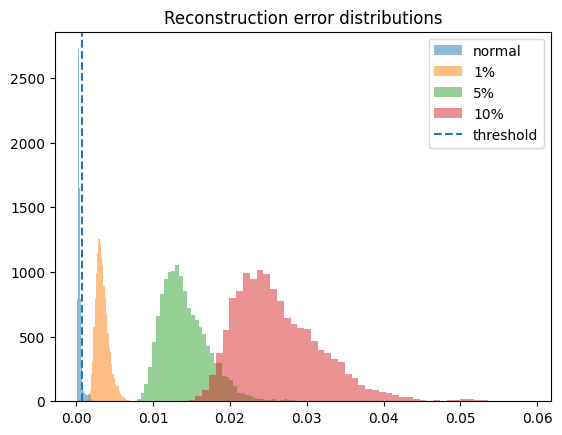

Threshold percentile 95
  False positives: 5.01%
  Detection 1%:    100.00%
  Detection 5%:    100.00%
  Detection 10%:   100.00%


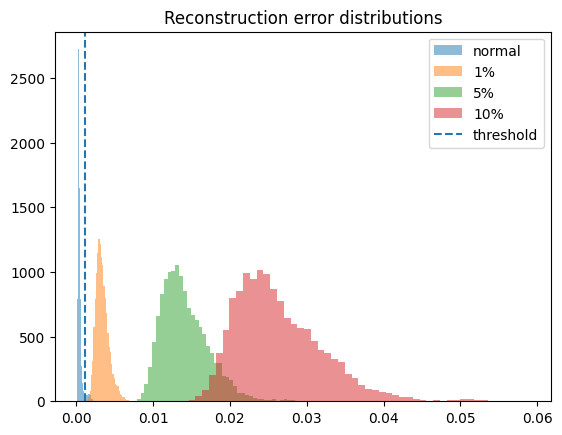

Threshold percentile 99
  False positives: 1.00%
  Detection 1%:    99.29%
  Detection 5%:    100.00%
  Detection 10%:   100.00%


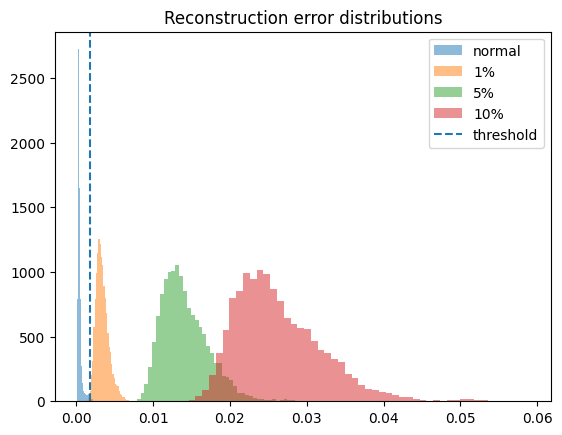

Threshold percentile 99.99
  False positives: 0.01%
  Detection 1%:    43.06%
  Detection 5%:    100.00%
  Detection 10%:   100.00%


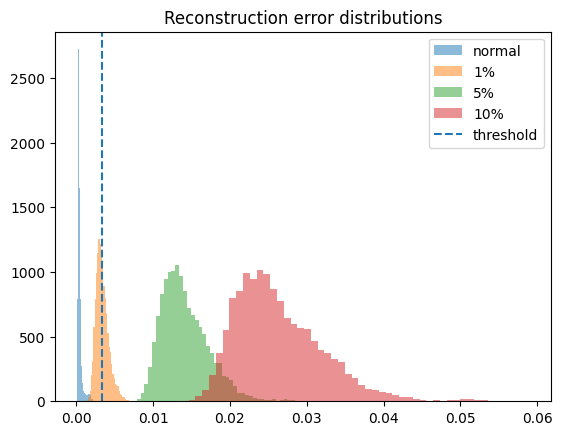

Threshold percentile 99.9999999999999
  False positives: 0.00%
  Detection 1%:    40.64%
  Detection 5%:    100.00%
  Detection 10%:   100.00%


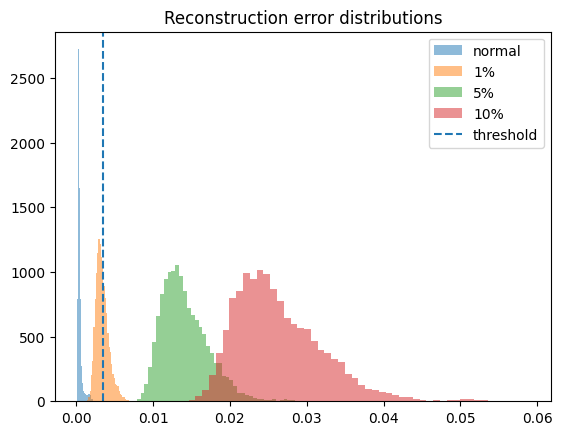

In [ ]:
for p in [90, 95, 99, 99.99, 99.9999999999999]:
    threshold = np.percentile(normal_errors, p)
    fp = (normal_errors > threshold).mean() * 100
    dr1 = (errs_1 > threshold).mean() * 100
    dr5 = (errs_5 > threshold).mean() * 100
    dr10 = (errs_10 > threshold).mean() * 100

    print(f"Threshold percentile {p}")
    print(f"  False positives: {fp:.2f}%")
    print(f"  Detection 1%:    {dr1:.2f}%")
    print(f"  Detection 5%:    {dr5:.2f}%")
    print(f"  Detection 10%:   {dr10:.2f}%")
    plt.hist(errs_normal, bins=50, alpha=0.5, label="normal")
    plt.hist(errs_1, bins=50, alpha=0.5, label="1%")
    plt.hist(errs_5, bins=50, alpha=0.5, label="5%")
    plt.hist(errs_10, bins=50, alpha=0.5, label="10%")
    plt.axvline(threshold, linestyle="--", label="threshold")
    plt.legend()
    plt.title("Reconstruction error distributions")
    plt.show()

In [35]:
print(max(normal_errors))
print(min(errs_5))

0.0034556538
0.007364627


In [33]:
    print(dr1,dr5,dr10)


40.64147944809651 100.0 100.0


In [23]:
normal_errors = reconstruction_errors(model, normal_test_loader)
threshold = np.percentile(normal_errors, 90)

fp_rate = (normal_errors > threshold).mean() * 100
print(f"False positive rate on normal test: {fp_rate:.2f}%")

False positive rate on normal test: 10.01%


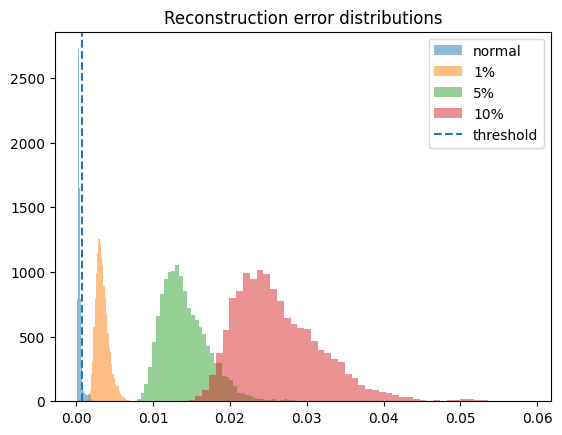

In [24]:
# sanity checks
import matplotlib.pyplot as plt

errs_normal = reconstruction_errors(model, normal_test_loader)
errs_1 = reconstruction_errors(model, anomaly_loader_1)
errs_5 = reconstruction_errors(model, anomaly_loader_5)
errs_10 = reconstruction_errors(model, anomaly_loader_10)

plt.hist(errs_normal, bins=50, alpha=0.5, label="normal")
plt.hist(errs_1, bins=50, alpha=0.5, label="1%")
plt.hist(errs_5, bins=50, alpha=0.5, label="5%")
plt.hist(errs_10, bins=50, alpha=0.5, label="10%")
plt.axvline(threshold, linestyle="--", label="threshold")
plt.legend()
plt.title("Reconstruction error distributions")
plt.show()

In [25]:
x_normal = normal_test[0][0]
x_anom = anomaly_test_1[0][0]

print("Normal min/max:", x_normal.min().item(), x_normal.max().item())
print("Anomaly min/max:", x_anom.min().item(), x_anom.max().item())
print("Fraction exactly black:", (x_anom == 0).float().mean().item())

Normal min/max: 0.0 1.0
Anomaly min/max: 0.0 1.0
Fraction exactly black: 0.01003333367407322


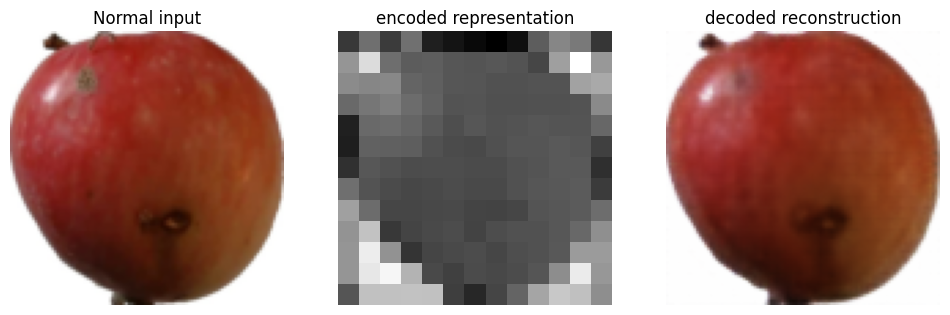

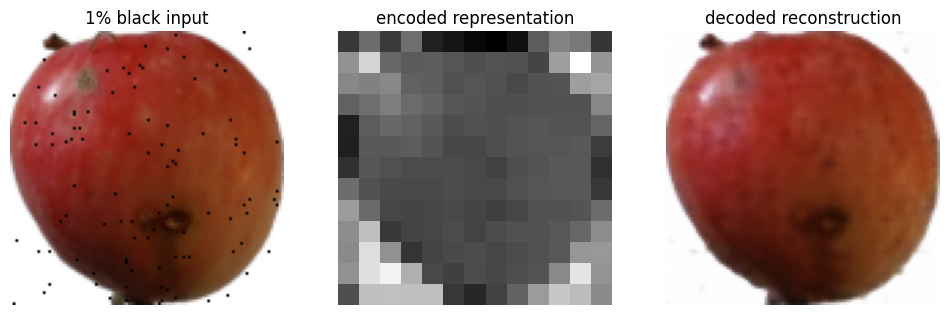

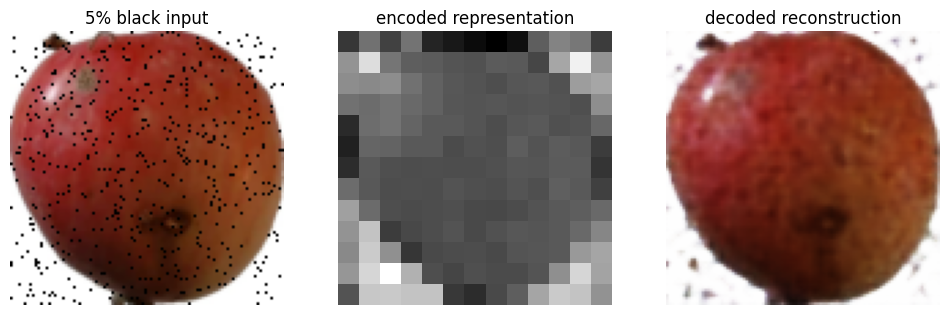

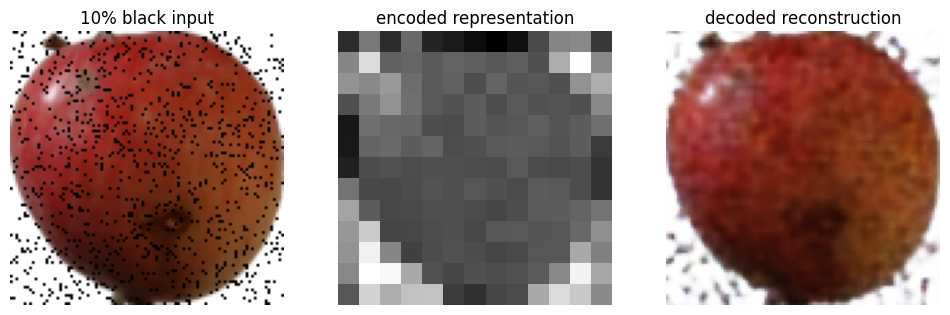

In [26]:
def show_ae_example(dataset, idx=0, title=""):
    model.eval()

    x = dataset[idx][0].unsqueeze(0).to(device)

    with torch.no_grad():
        z = model.encoder(x)
        x_hat = model.decoder(z)

    x_img = x[0].cpu().permute(1, 2, 0)
    xhat_img = x_hat[0].cpu().permute(1, 2, 0)

    # Show average encoded feature map
    z_img = z[0].mean(dim=0).cpu()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(x_img)
    plt.title(f"{title} input")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(z_img, cmap="gray")
    plt.title("encoded representation")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(xhat_img)
    plt.title("decoded reconstruction")
    plt.axis("off")

    plt.show()


show_ae_example(normal_test, idx=0, title="Normal")
show_ae_example(anomaly_test_1, idx=0, title="1% black")
show_ae_example(anomaly_test_5, idx=0, title="5% black")
show_ae_example(anomaly_test_10, idx=0, title="10% black")